In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import StandardScaler
import hdbscan
import umap

In [381]:
df = pd.read_excel('./las3.18.xlsx')

In [396]:
nan_columns = df.columns[df.isna().any()].tolist()
print("Columns with NaNs:", nan_columns)

Columns with NaNs: []


In [382]:
rows_of_users = []
for i,j in df.iterrows():
    sentenc  = f"User is an {j['Job_Seniority']} in {j['Job_Function']} from the {j['Parent_Industry']} industry, working in a company with a turnover of {j['Turnover_Range']} and {j['Employees_Range']} employees. Their key areas of interest include {j['aoi_1']}, {j['aoi_2']}, {j['aoi_3']}, {j['aoi_4']}, and {j['aoi_5']}."
    rows_of_users.append(sentenc)

In [145]:
base = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

In [146]:
embedding = base.encode(rows_of_users, normalize_embeddings=True)

In [ ]:
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv()
client = OpenAI()
def batch(iterable, n=100):
    l = len(iterable)
    for ndx in range(0, l, n):
        yield iterable[ndx:min(ndx + n, l)]

all_embeddings = []
for batch_rows in batch(rows_of_users, 100):  # Adjust batch size as needed
    response = client.embeddings.create(
        input=batch_rows,
        model="text-embedding-3-large"
    )
    all_embeddings.extend([item.embedding for item in response.data])

# response = client.embeddings.create(
#     input=rows_of_users,
#     model="text-embedding-3-small"
# )

In [400]:
scaler = StandardScaler()
ae=all_embeddings
print(type(all_embeddings))

<class 'list'>


In [386]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [ ]:
embeddings_scaled = scaler.fit_transform(embedding)

#openai_embeddings = [item.embedding for item in  all_embeddings.data]
openai_embeddings = np.array(all_embeddings)
openai_embeddings_scaled = scaler.fit_transform(all_embeddings)



In [218]:
embedding,openai_embeddings

(array([[ 0.04723771,  0.02098009, -0.0496204 , ...,  0.06054819,
         -0.01202563, -0.07589705],
        [ 0.05303754,  0.05632244, -0.04097369, ...,  0.04704805,
          0.01485726, -0.06211974],
        [ 0.06685901,  0.01865205, -0.04642908, ...,  0.04760582,
         -0.01173509, -0.07876274],
        ...,
        [ 0.03330714,  0.03981395, -0.05607043, ...,  0.05319302,
          0.01008218, -0.06915522],
        [ 0.05176476,  0.04130324, -0.04794653, ...,  0.04953412,
         -0.00020367, -0.07657173],
        [ 0.05282364,  0.01741354, -0.0411423 , ...,  0.04270382,
          0.01560369, -0.086133  ]], shape=(99, 768), dtype=float32),
 array([[-0.03591963,  0.01751494, -0.01539765, ..., -0.01926149,
          0.00678848, -0.02222733],
        [-0.02735035,  0.01313472, -0.01812984, ..., -0.00675161,
          0.00926145, -0.01252057],
        [-0.0350939 ,  0.02437431, -0.02129562, ..., -0.02482096,
         -0.00051544, -0.01202764],
        ...,
        [-0.03948748, 

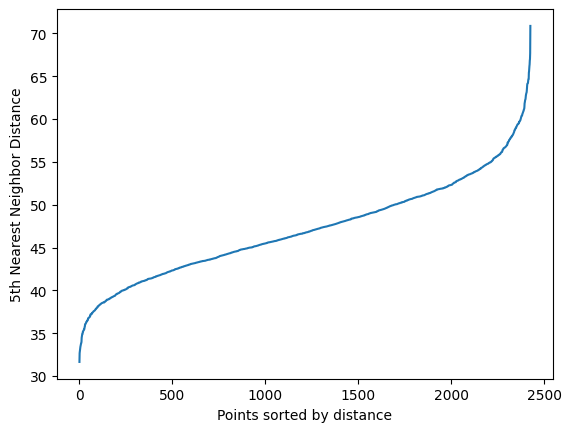

In [239]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=15)
neighbors_fit = neighbors.fit(openai_embeddings_scaled)
distances, indices = neighbors_fit.kneighbors(openai_embeddings_scaled)
distances = np.sort(distances[:, 4])
plt.plot(distances)
plt.ylabel("5th Nearest Neighbor Distance")
plt.xlabel("Points sorted by distance")
plt.show()

In [ ]:
# DBSCAN
db = DBSCAN(eps=21, min_samples=10, metric='cosine')  # You can use 'cosine'
labels = db.fit_predict(embeddings_scaled)
labels1 = db.fit_predict(openai_embeddings)


In [277]:
from kneed import KneeLocator

kneedle = KneeLocator(
    range(len(distances)), distances, S=1.0, curve="convex", direction="increasing"
)
print("Elbow at index:", kneedle.knee)
print("Suggested eps:", distances[kneedle.knee])

Elbow at index: 2358
Suggested eps: 59.40131282216831


In [306]:
labels,labels1


(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([0, 0, 0, ..., 0, 0, 0], shape=(2425,)))

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=20)
reduced = pca.fit_transform(openai_embeddings_scaled)
db = DBSCAN(eps=24, min_samples=1)
labels4 = db.fit_predict(reduced)
n_clusters = len(set(labels4)) - (1 if -1 in labels else 0)
print(n_clusters)

26


In [388]:
labels4

array([17, -1,  0, ...,  1, 21, -1], shape=(2425,))

In [309]:
import tiktoken

def num_tokens_from_string(string: str, encoding_name: str) -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

num_tokens_from_string(str(rows_of_users), "cl100k_base")

180534

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=12, random_state=42)
labels2 = kmeans.fit_predict(openai_embeddings_scaled)

In [368]:
labels4

array([ 0, -1,  2, ...,  1, -1, -1], shape=(2425,))

In [399]:
df['cluster'] = labels4

In [395]:
df.to_excel("db_funtion_24_min_10.xlsx")

In [ ]:
  # pip install hdbscan umap-learn

# X = matrix of shape (n_customers, embedding_dim)
X_std = StandardScaler().fit_transform(embedding)           # stabilise high-dim space
X_2d  = umap.UMAP(n_components=2).fit_transform(X_std)  # for plotting only

clusterer = hdbscan.HDBSCAN(min_cluster_size=15, metric="euclidean")
labels = clusterer.fit_predict(X_std)

c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\abhinash\Documents\Internship\clustering\.venv\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


ValueError: 'c' argument has 99 elements, which is inconsistent with 'x' and 'y' with size 2425.

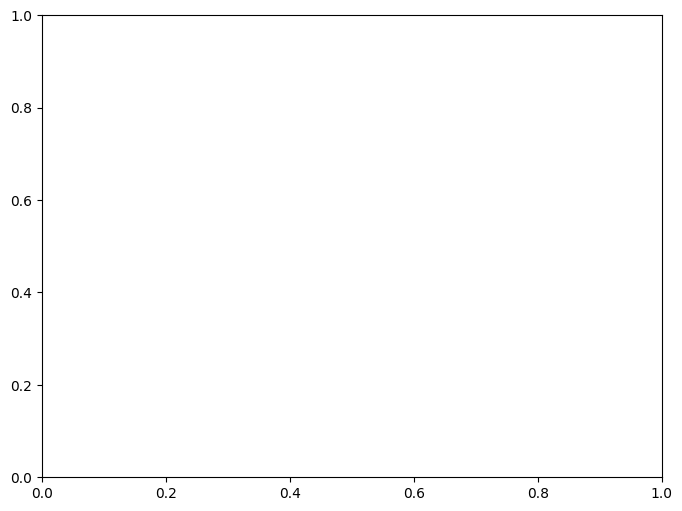

In [248]:
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
X_2d = umap.UMAP(n_components=2).fit_transform(openai_embeddings_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, cmap='tab10', s=30)
plt.title("Cluster visualization")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(scatter, label='Cluster')
plt.show()

In [364]:
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

# Reduce dimensions
pca = PCA(n_components=20)
reduced = pca.fit_transform(openai_embeddings_scaled)
db = DBSCAN(eps=21, min_samples=10)
labels5 = db.fit_predict(reduced)
# Try a range of eps values
for eps in range(1,100):
    db = DBSCAN(eps=24, min_samples=eps)
    labels6 = db.fit_predict(reduced)
    n_clusters = len(set(labels6)) - (1 if -1 in labels else 0)
    print(f" clusters={n_clusters}")

 clusters=470
 clusters=97
 clusters=52
 clusters=32
 clusters=30
 clusters=26
 clusters=22
 clusters=23
 clusters=23
 clusters=20
 clusters=17
 clusters=17
 clusters=17
 clusters=14
 clusters=13
 clusters=13
 clusters=13
 clusters=11
 clusters=10
 clusters=9
 clusters=8
 clusters=8
 clusters=8
 clusters=8
 clusters=8
 clusters=7
 clusters=6
 clusters=6
 clusters=6
 clusters=7
 clusters=8
 clusters=8
 clusters=8
 clusters=8
 clusters=7
 clusters=7
 clusters=7
 clusters=6
 clusters=5
 clusters=5
 clusters=5
 clusters=5
 clusters=5
 clusters=5
 clusters=4
 clusters=3
 clusters=3
 clusters=3
 clusters=3
 clusters=3
 clusters=3
 clusters=3
 clusters=3
 clusters=3
 clusters=3
 clusters=3
 clusters=3
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 clusters=2
 cluster

In [285]:
labels5

array([-1, -1, -1, ...,  0, -1, -1], shape=(2425,))